# Project Overview

# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import pickle

# Loading Dataset

In [4]:
df = pd.read_csv('Flight_Fare.csv')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
df.shape

(10683, 11)

In [7]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [8]:
# Dropping null values
df.dropna(inplace = True)

# Exploratory Data Analysis

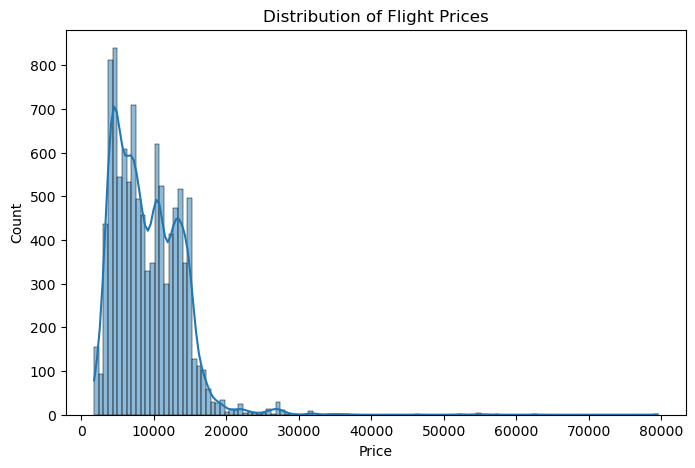

count    10682.000000
mean      9087.214567
std       4611.548810
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64


In [9]:
#plot for price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Flight Prices")
plt.show()

print(df['Price'].describe())

<Axes: xlabel='price range', ylabel='percent'>

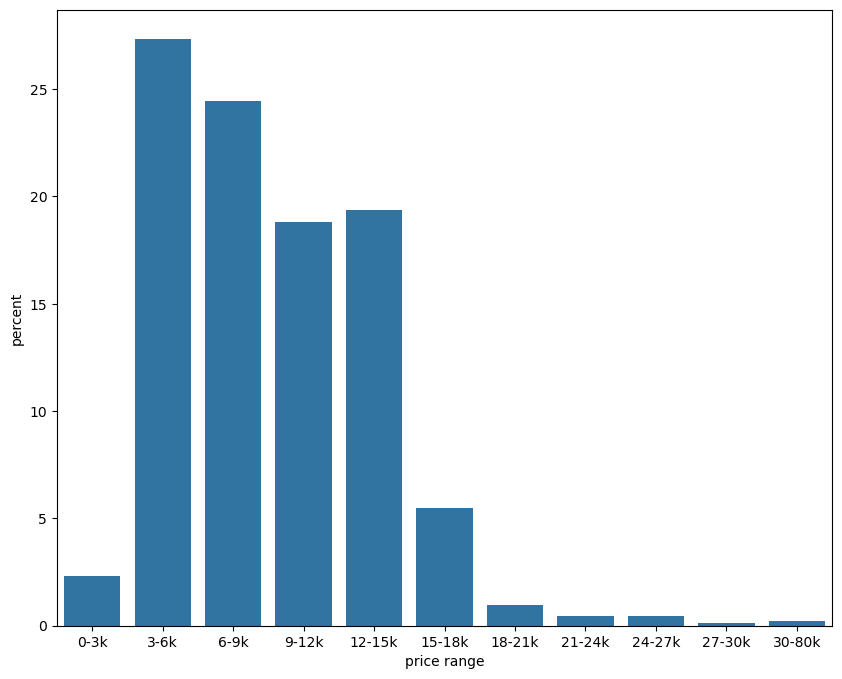

In [10]:
#analyzing the majority distribution more deeply using bins and labels in countplot
labels = ['0-3k','3-6k','6-9k','9-12k','12-15k','15-18k','18-21k','21-24k','24-27k','27-30k','30-80k']
bins = [0,3000,6000,9000,12000,15000,18000,21000,24000,27000,30000,80000]

df['price range'] = pd.cut(df['Price'], bins = bins , labels = labels, include_lowest = True,)

plt.figure(figsize = (10,8))
sns.countplot(x = 'price range', data = df, stat = 'percent')

Text(0, 0.5, 'Percent')

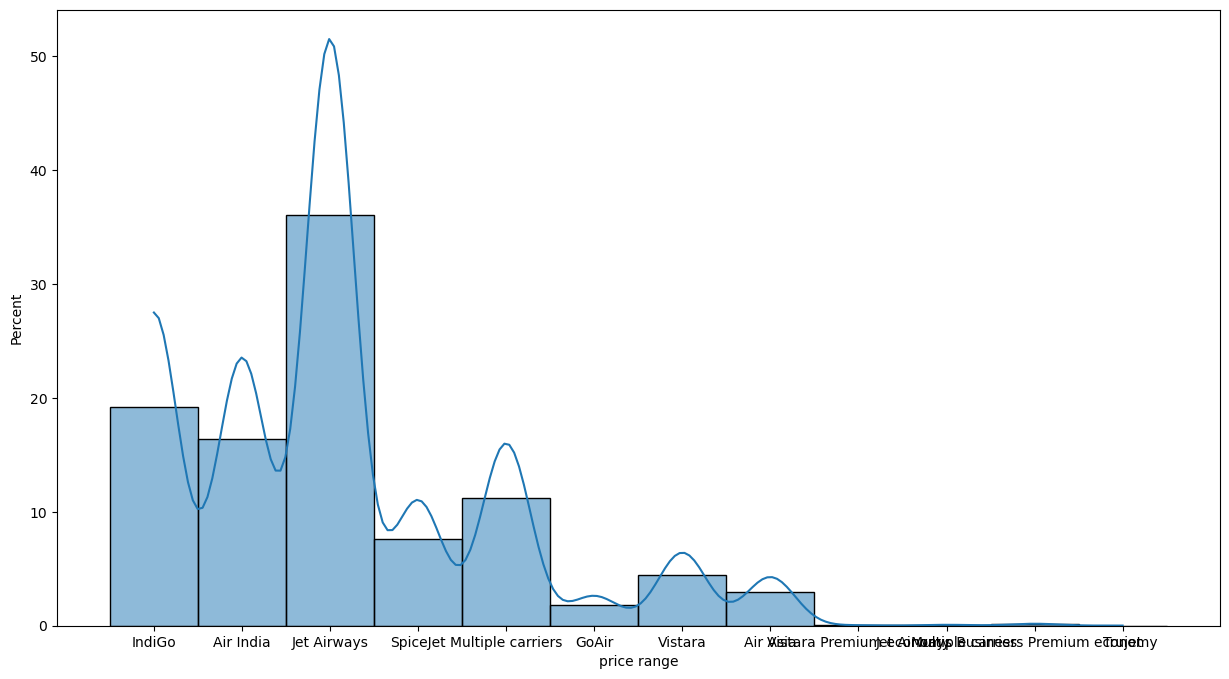

In [16]:
# histplot for airlines
plt.figure(figsize = (15,8))
sns.histplot(x = df['Airline'], data = df,stat = 'percent', kde = True)
plt.xlabel("price range")
plt.ylabel("Percent")

(array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45.]),
 [Text(0, 0.0, '0'),
  Text(0, 5.0, '5'),
  Text(0, 10.0, '10'),
  Text(0, 15.0, '15'),
  Text(0, 20.0, '20'),
  Text(0, 25.0, '25'),
  Text(0, 30.0, '30'),
  Text(0, 35.0, '35'),
  Text(0, 40.0, '40'),
  Text(0, 45.0, '45')])

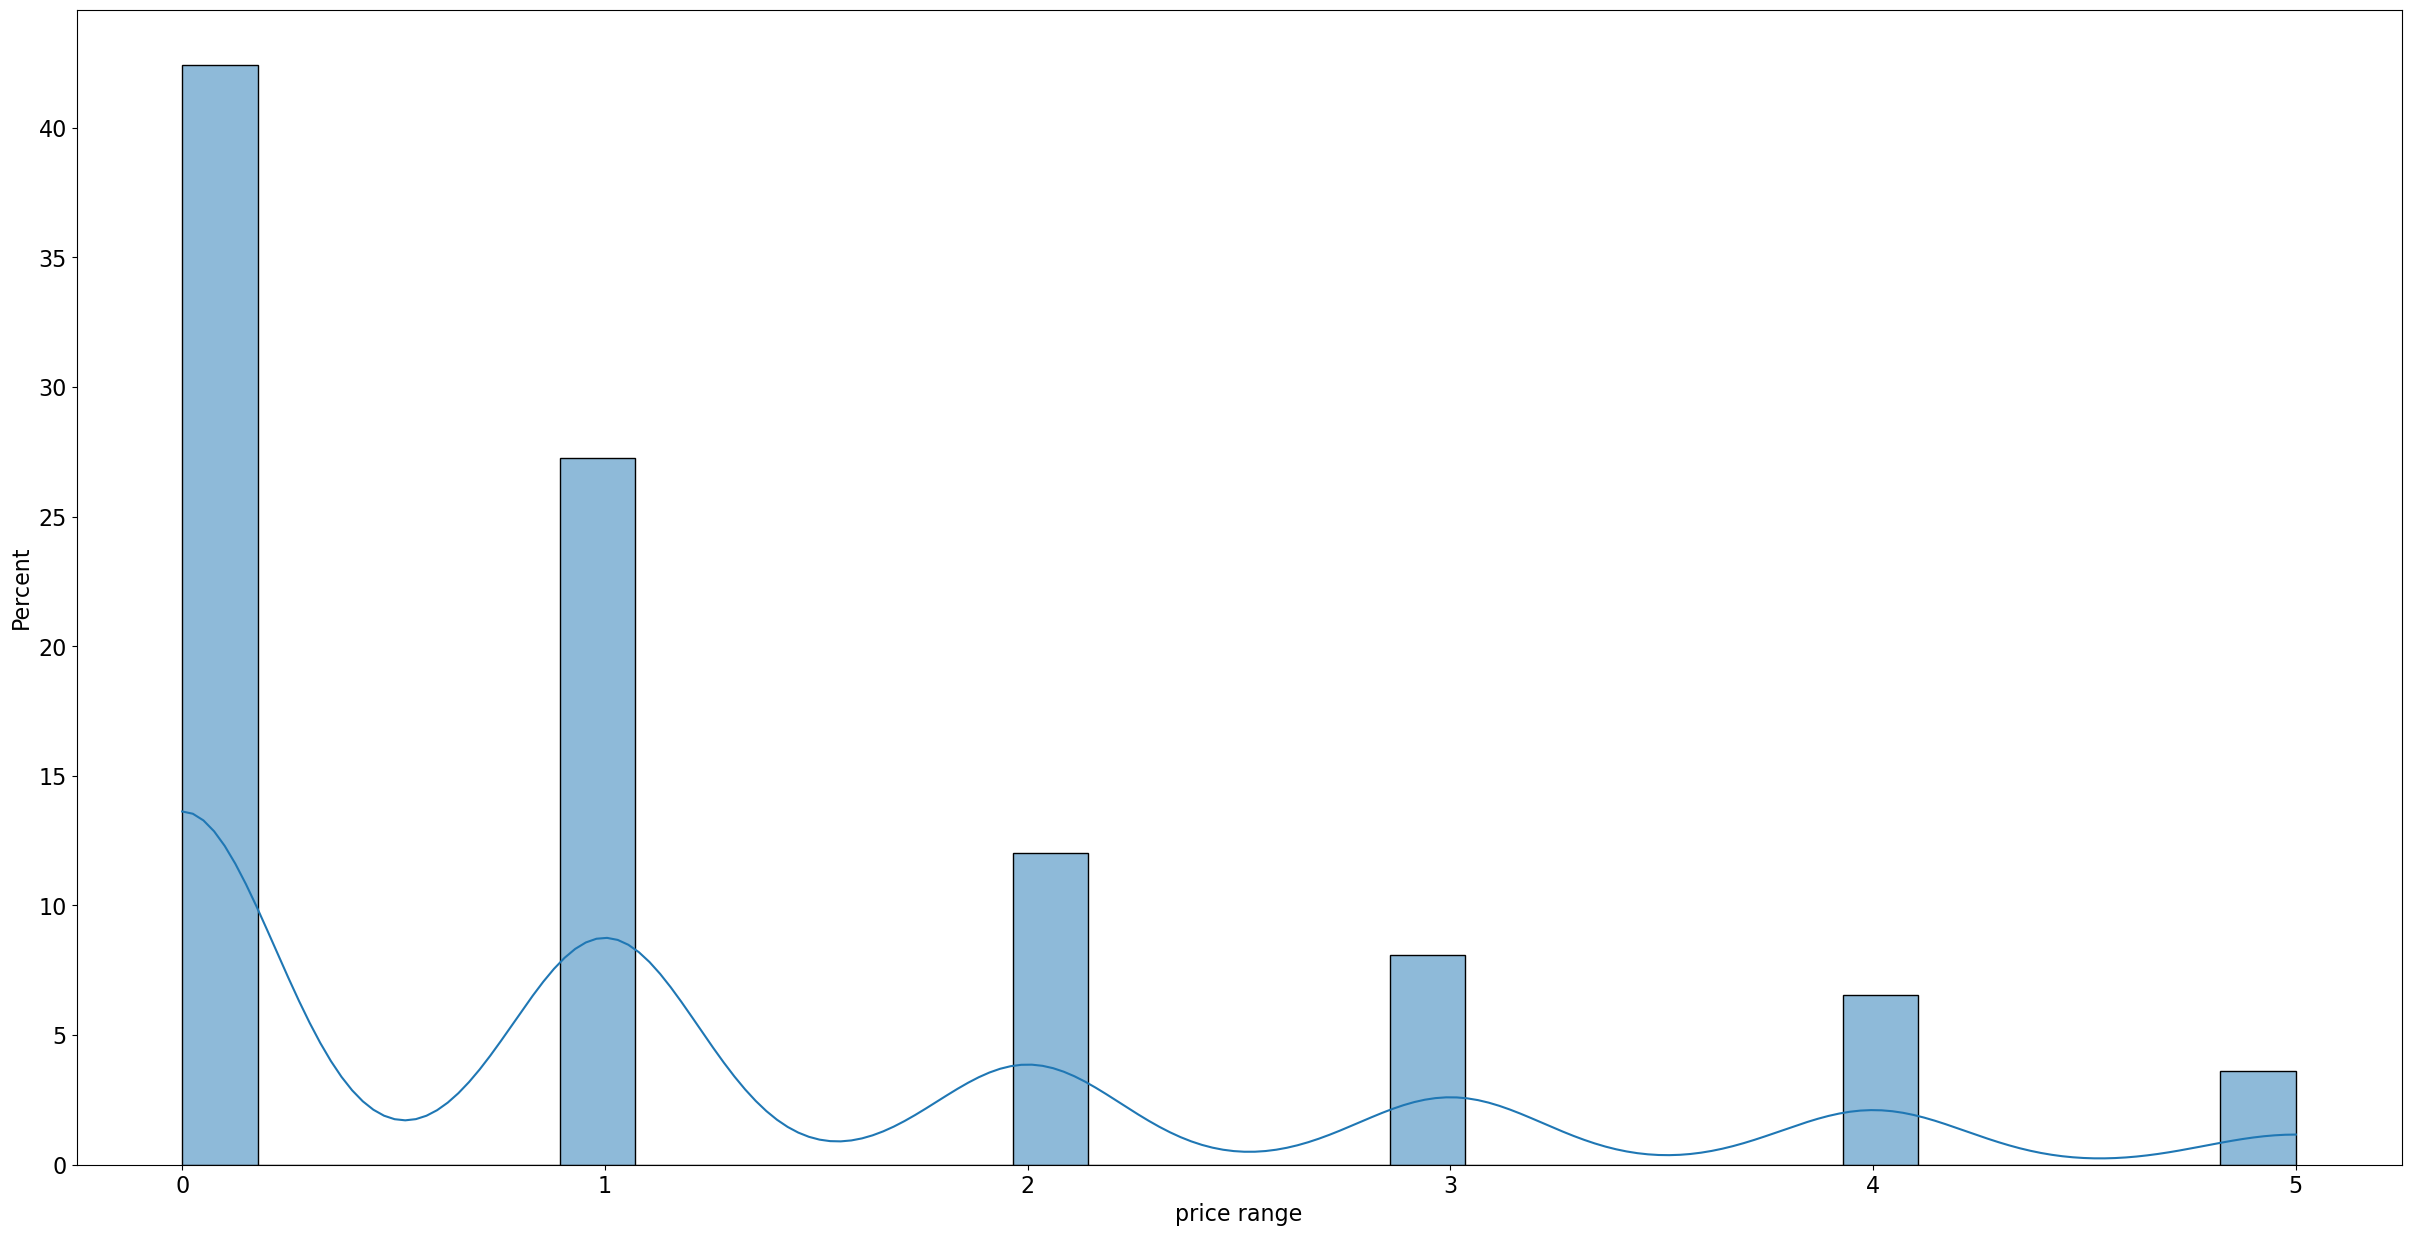

In [176]:
# histplot for Destination
plt.figure(figsize = (30,15))
sns.histplot(x = df['Destination'], data = df,stat = 'percent', kde = True)
plt.xlabel("price range", fontsize = 16)
plt.ylabel("Percent", fontsize = 16)
plt.xticks(fontsize=16)                  # X-axis ticks
plt.yticks(fontsize=16) 

In [15]:
# Checking price range with respect to highly influential columns

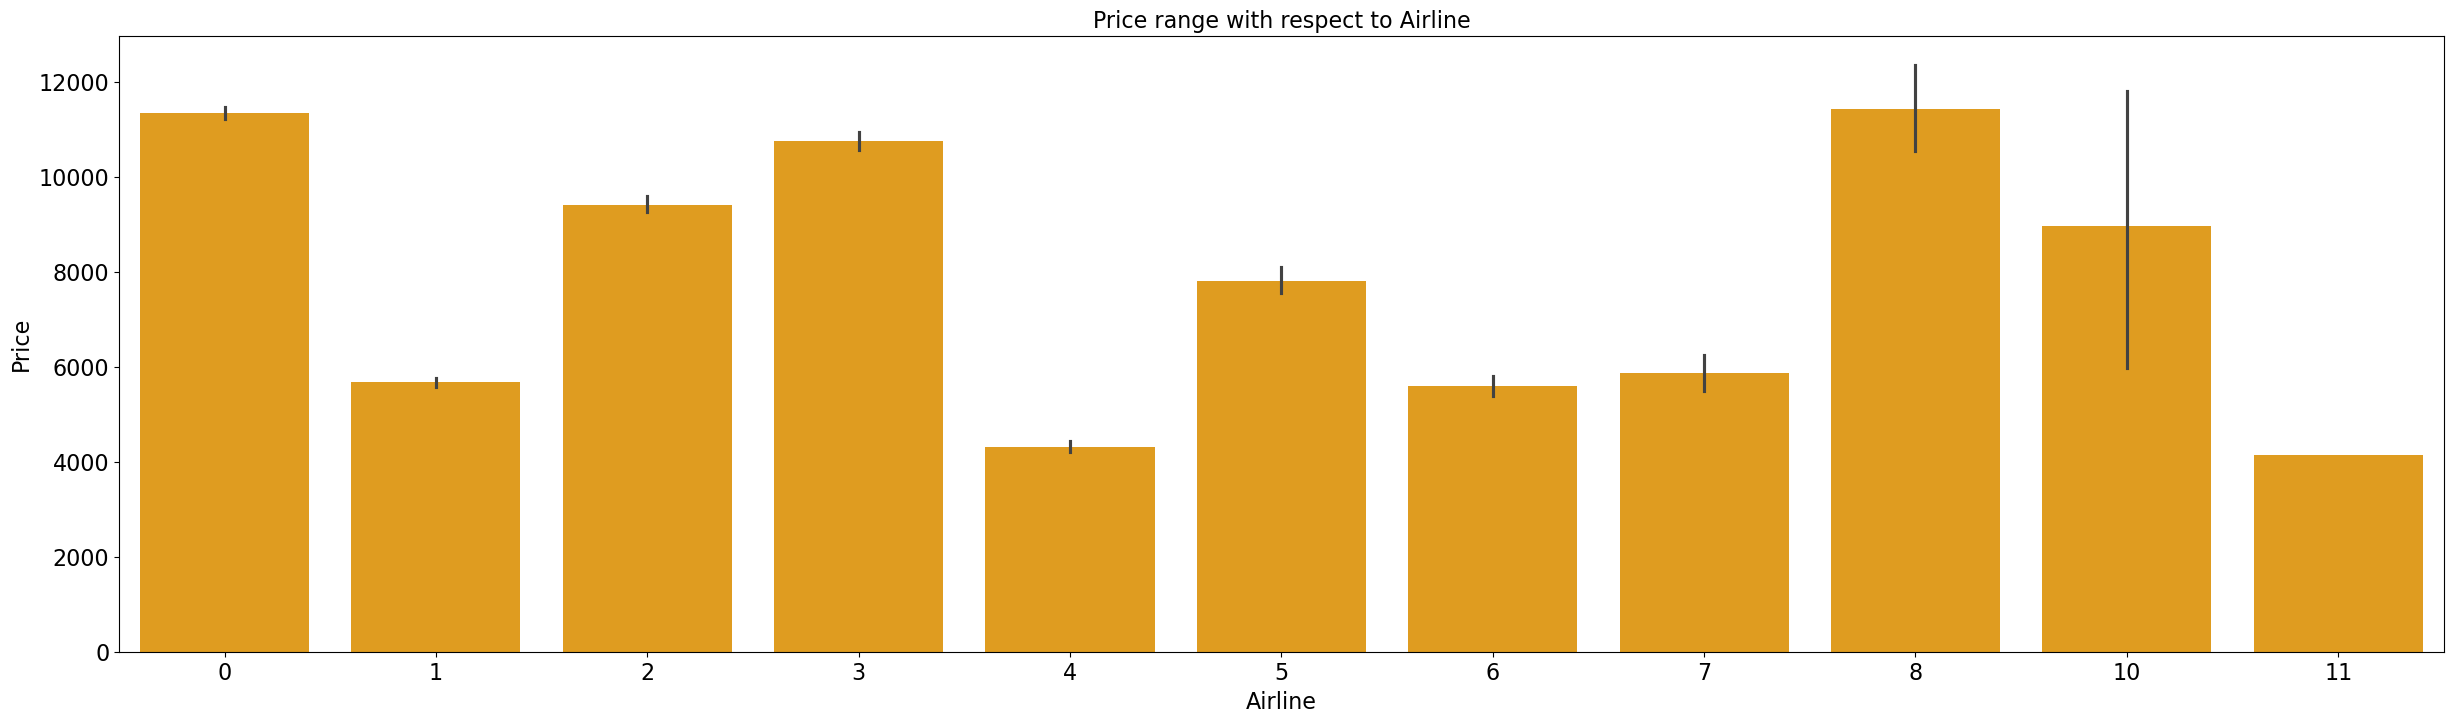

In [177]:
plt.figure(figsize = (30,8))
sns.barplot(x = df['Airline'], y= df['Price'],data = df,color = 'orange')
plt.title("Price range with respect to Airline", fontsize = 16)
plt.xlabel("Airline",fontsize = 16)
plt.ylabel("Price", fontsize = 16)
plt.xticks(fontsize=16)                  # X-axis ticks
plt.yticks(fontsize=16)
plt.show()

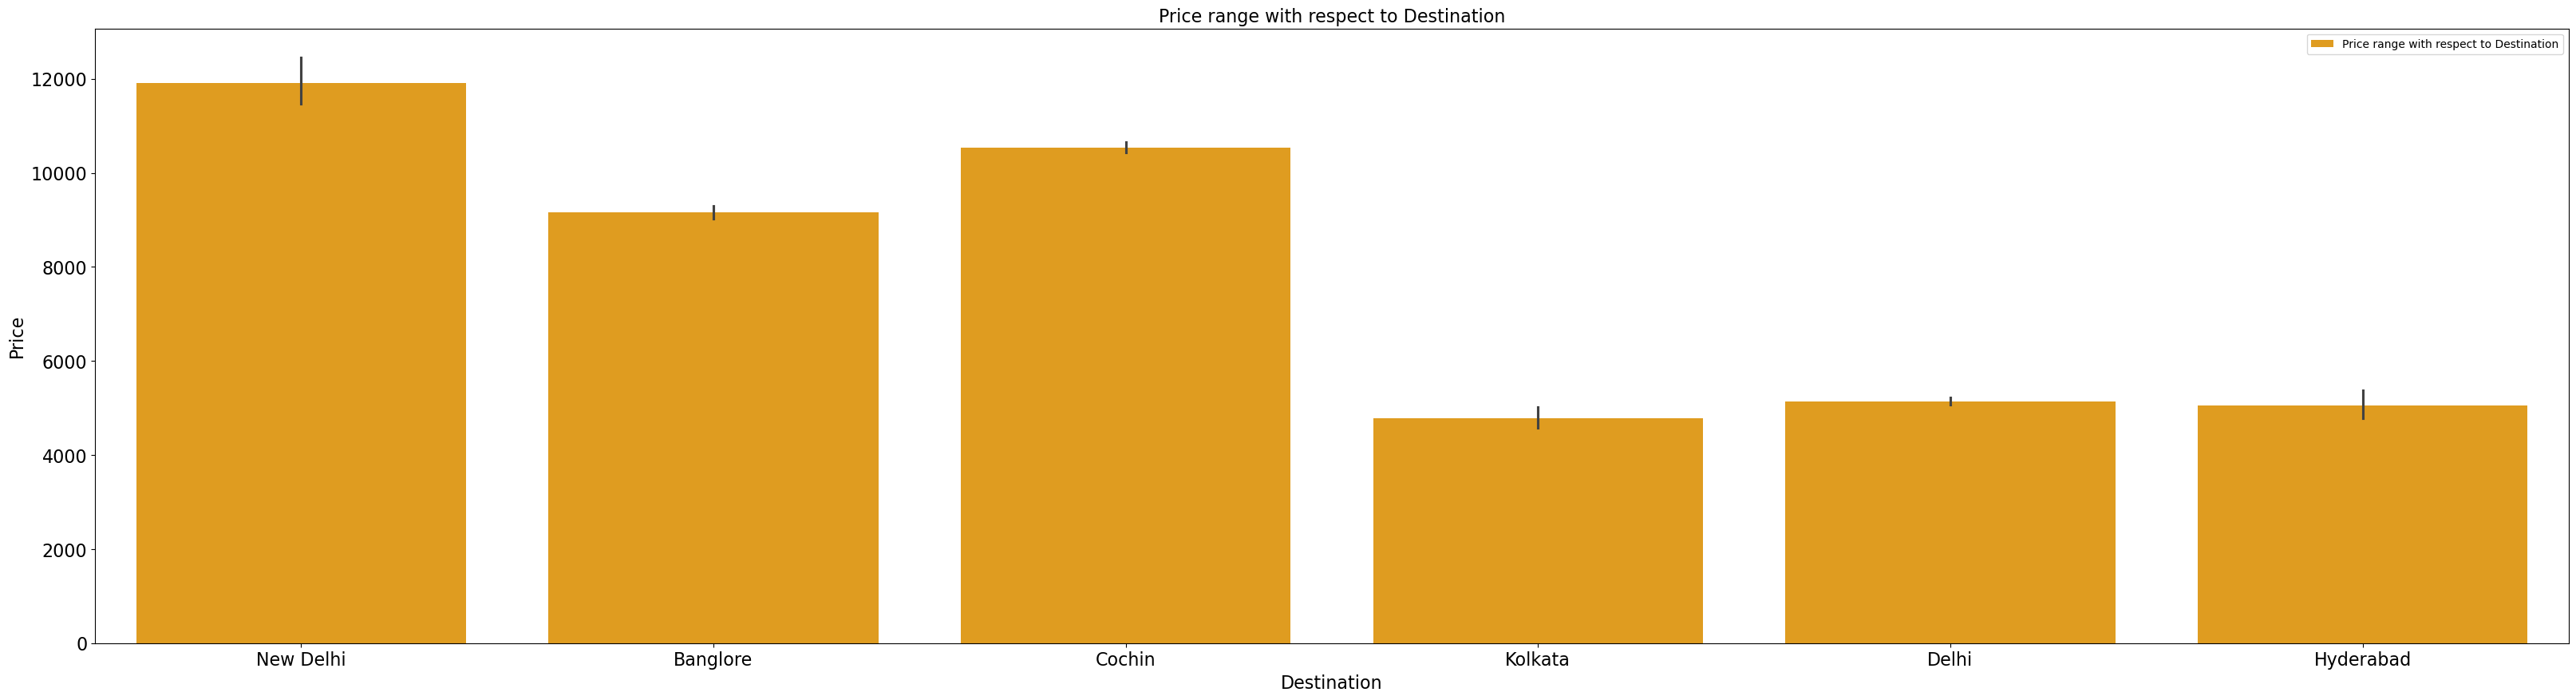

In [13]:
plt.figure(figsize=(40, 10))
sns.barplot(x="Destination", y="Price", data=df,color = 'orange', label = "Price range with respect to Destination") 
plt.title("Price range with respect to Destination",fontsize = 16)
plt.xlabel("Destination", fontsize = 16)
plt.ylabel("Price", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()

# Feature Engineering

In [18]:
# As we can see that Date of journey is an object data type.
# Therefore we have to convert this datatype into timestamp so as to use this column properly for prediction.

In [19]:
df['Journey_day'] = pd.to_datetime(df['Date_of_Journey'],format = "%d/%m/%Y").dt.day
df['Jorney_month'] = pd.to_datetime(df['Date_of_Journey'],format = "%d/%m/%Y").dt.month

In [20]:
#since we don't require the Duration column now , so we ca drop it
df.drop('Date_of_Journey',axis = 1, inplace = True)

In [21]:
# similar to Date of journey we can extract values from departure time and create new columns
df['Dep_hr'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_min'] = pd.to_datetime(df['Dep_Time']).dt.minute

In [22]:
# as now we don't need dep_time so we will drop it also
df.drop('Dep_Time',axis = 1, inplace = True)

In [23]:
# similar to previous columns we can extract values from arrival time
# extracting hours and minutes
df['Arrival_hr'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_min'] = pd.to_datetime(df['Arrival_Time']).dt.minute

In [24]:
df.drop("Arrival_Time",axis = 1, inplace = True)

In [25]:
# similar to Date of journey we can extract values from "Duration" time and create new columns
df["Duration_Hours"] = df["Duration"].str.extract(r'(\d+)h').fillna(0).astype(int)

# Create Minutes column (extracting number before 'm', else 0)
df["Duration_Minutes"] = df["Duration"].str.extract(r'(\d+)m').fillna(0).astype(int)

In [54]:
# Converting Duration columns into total minutes
df["Total_duration_mins"] = df["Duration_Hours"] * 60 + df["Duration_Minutes"]

print(df[["Duration_Hours", "Duration_Minutes", "Duration_total_mins"]].head())

   Duration_Hours  Duration_Minutes  Duration_total_mins
0               2                50                  170
1               7                25                  445
2              19                 0                 1140
3               5                25                  325
4               4                45                  285


In [26]:
# Now we can drop Duration column also
df.drop("Duration",axis = 1, inplace = True)

# Encoding - Handling Categorical data

In [27]:
df['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [28]:
df['Airline'] = df['Airline'].map({"Jet Airways" : 0,"IndiGo":1,"Air India" : 2,"Multiple carriers" : 3, "SpiceJet" : 4, 
                                           "Vistara" : 5, "Air Asia": 6, "GoAir" : 7, "Multiple carriers Premium economy" : 8, "Jet Airways Business" : 9, 
                                           "Vistara Premium economy" : 10, "Trujet" : 11})

In [30]:
df.Destination.value_counts()

Destination
0    4536
1    2871
2    1265
3     932
4     697
5     381
Name: count, dtype: int64

In [29]:
df["Destination"] = df['Destination'].map({"Cochin" : 0, "Banglore" : 1, "Delhi" : 2 , "New Delhi" : 3, "Hyderabad" : 4, "Kolkata" : 5})

In [31]:
df['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [32]:
df["Total_Stops"] = df["Total_Stops"].map({"1 stop" : 1, "non-stop" : 0, "2 stops" : 2, "3 stop" : 3, "4 stops" : 4})

In [35]:
df["Total_Stops"].dtype

dtype('float64')

In [39]:
df.Total_Stops.isnull().sum()

45

In [40]:
# Filling Nan values in "Total_Stops" using mode
# Fill NaN in Total_Stops with the mode
df['Total_Stops'] = df['Total_Stops'].fillna(df['Total_Stops'].mode()[0])

In [41]:
df.Total_Stops.isnull().sum()

0

In [42]:
# now converting the data type of "Total_Stops" from float to int.
df['Total_Stops'] = df['Total_Stops'].astype(int)

In [44]:
df.Source.value_counts()

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [45]:
df["Source"] = df["Source"].map({"Delhi":0, "Kolkata": 1,"Banglore": 2,"Mumbai":3,"Chennai": 4})

# Dropping unwanted / unnecessary columns

In [48]:
df['Route'].value_counts()

Route
DEL ? BOM ? COK          2376
BLR ? DEL                1552
CCU ? BOM ? BLR           979
CCU ? BLR                 724
BOM ? HYD                 621
                         ... 
CCU ? VTZ ? BLR             1
CCU ? IXZ ? MAA ? BLR       1
BOM ? COK ? MAA ? HYD       1
BOM ? CCU ? HYD             1
BOM ? BBI ? HYD             1
Name: count, Length: 128, dtype: int64

In [49]:
df['Additional_Info'].value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [50]:
# As Route and Additional info columns are of no use so, we will drop them.
df.drop(['Route', 'Additional_Info'], axis=1, inplace=True)

In [172]:
df.shape

(10516, 16)

# Removing Outliers

<Axes: ylabel='Price'>

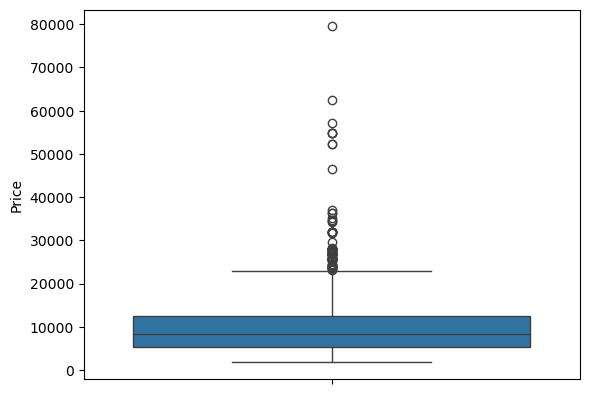

In [56]:
sns.boxplot(df['Price'])

In [57]:
# Removing outliers using IQR method
q1 = df["Price"].quantile(0.25)
q3 = df["Price"].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

# Keep only non-outliers
df= df[(df["Price"] >= lower_bound) & (df["Price"] <= upper_bound)]

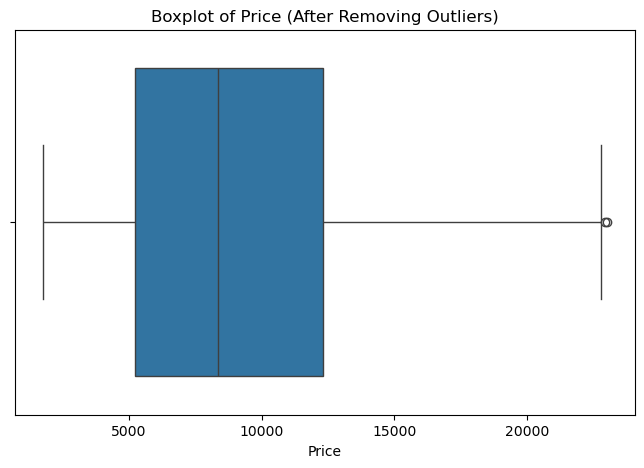

In [58]:
# Boxplot of Price after removing outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of Price (After Removing Outliers)")
plt.show()

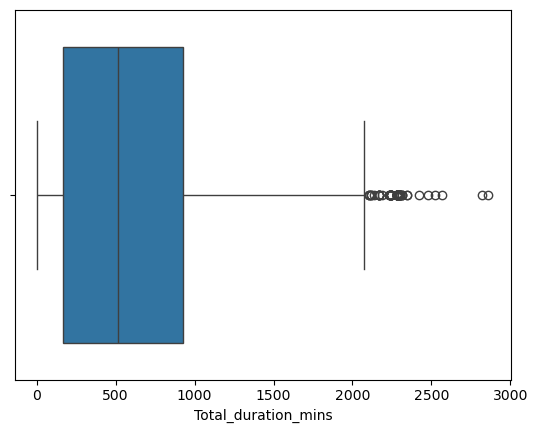

In [67]:
sns.boxplot(x=df['Total_duration_mins'])
plt.show()

In [70]:
Q1 = df['Total_duration_mins'].quantile(0.25)
Q3 = df['Total_duration_mins'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['Total_duration_mins'] >= lower_bound) & (df['Total_duration_mins'] <= upper_bound)]


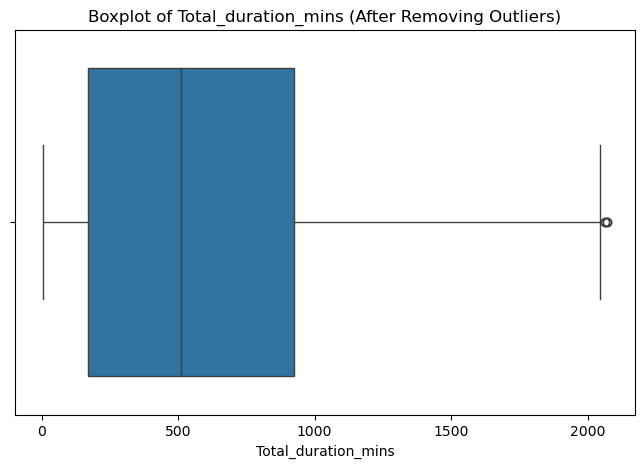

In [71]:
# Boxplot of Price after removing outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Total_duration_mins"])
plt.title("Boxplot of Total_duration_mins (After Removing Outliers)")
plt.show()

# Splitting data into training and testing sets

In [76]:
X = df[['Airline','Source','Destination','Total_Stops','Journey_day','Jorney_month','Dep_hr','Dep_min',
        'Arrival_hr','Arrival_min','Total_duration_mins']]
y = df['Price']

In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression

In [78]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [79]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.5297730645745853
Linear Regression MAE: 2130.834018911767
Linear Regression RMSE: 2765.602732246598


# Random Forest Regressor

In [80]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [103]:
print("Random Forest (Default)")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest (Default)
R2 Score: 0.8280414955959291
MAE: 1078.4246780827257
RMSE: 1672.4297095023737


In [82]:
# Using new parameters to train RandomForest with the help of Grid Search Cv

In [84]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=3, n_jobs=-1, verbose=2, scoring="r2")

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 300}
Best Score: 0.8340817193112136


In [85]:
#Now let's try with other parameters.
#This time we fix the exact parameter instead of giving a range in the form of a list and see the performance.

In [110]:
best_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    random_state=42
)
best_rf.fit(X_train, y_train)
y_pred_rf_tuned = best_rf.predict(X_test)


In [104]:
print("Random Forest (Tuned)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Random Forest (Tuned)
R2 Score: 0.8373547638557106
MAE: 1076.5974822266478
RMSE: 1626.5099259528813


# Decision Trees

In [126]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [127]:
print("Decision Tree (Default)")
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree (Default)
R2 Score: 0.7034624508676153
MAE: 1306.5122069074778
RMSE: 2196.2202478905137


In [128]:
# Tuning Decision Tree with new parameters using Grid Search Cv

In [129]:
dt = DecisionTreeRegressor(random_state=42)
params_dt = {'max_depth':[None,5,10,15], 'min_samples_split':[2,5,10], 'min_samples_leaf':[1,2,5]}
grid_dt = GridSearchCV(dt, params_dt, cv=5, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test)

In [105]:
print("Decision Tree : (Tuned)")
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_dt))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree : (Tuned)
Decision Tree R2: 0.8053453521270658
Decision Tree MAE: 1143.477499292063
Decision Tree RMSE: 1779.3788874047984


# XGBoost

In [94]:
import xgboost as xgb
xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgbr.fit(X_train, y_train)

y_pred_xgb = xgbr.predict(X_test)


In [95]:
print("XGBoost (Default)")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost (Default)
R2 Score: 0.8436679840087891
MAE: 1102.4538005640297
RMSE: 1594.6303921881056


In [96]:
# Tuning XGBoost with new parameters

In [97]:
params_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_xgb = GridSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=params_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
y_pred_xgb_tuned = grid_xgb.predict(X_test)

In [106]:
print("XGBoost : (Tuned)")
print("XGBoost R2:", r2_score(y_test, y_pred_xgb_tuned))
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb_tuned))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)))

XGBoost : (Tuned)
XGBoost R2: 0.8456519842147827
XGBoost MAE: 1122.0703592626767
XGBoost RMSE: 1584.4793881577637


# K-Fold Cross Validation for all models

In [136]:
from sklearn.model_selection import cross_val_score

In [140]:
# Random Froest
cv_scores_rf = cross_val_score(best_rf, X, y, cv=5, scoring='r2')

print("Best Random Forest CV R² scores for each fold:", cv_scores_rf)
print("Mean CV R²:", np.mean(cv_scores_rf))

Best Random Forest CV R² scores for each fold: [0.84824389 0.83968669 0.85087244 0.83554298 0.83538923]
Mean CV R²: 0.8419470455481335


In [144]:
# for tuned Decision Tree
cv_scores_dt = cross_val_score(best_dt, X, y, cv=5, scoring='r2')

print("Tuned Decision Tree CV R² scores for each fold:", cv_scores_dt)
print("Mean CV R²:", np.mean(cv_scores_dt))

Tuned Decision Tree CV R² scores for each fold: [0.81669119 0.79329495 0.80660514 0.79112369 0.79126923]
Mean CV R²: 0.799796842141194


In [143]:
# for tuned XGBoost
best_xgb = grid_xgb.best_estimator_

# K-Fold Cross-Validation (5 folds)
cv_scores_xgb = cross_val_score(best_xgb, X, y, cv=5, scoring='r2')

print("Tuned XGBoost CV R² scores for each fold:", cv_scores_xgb)
print("Mean CV R²:", np.mean(cv_scores_xgb))

Tuned XGBoost CV R² scores for each fold: [0.85674763 0.84735024 0.85594136 0.84554422 0.84166843]
Mean CV R²: 0.8494503736495972


# Actual VS Predicted graphs for models

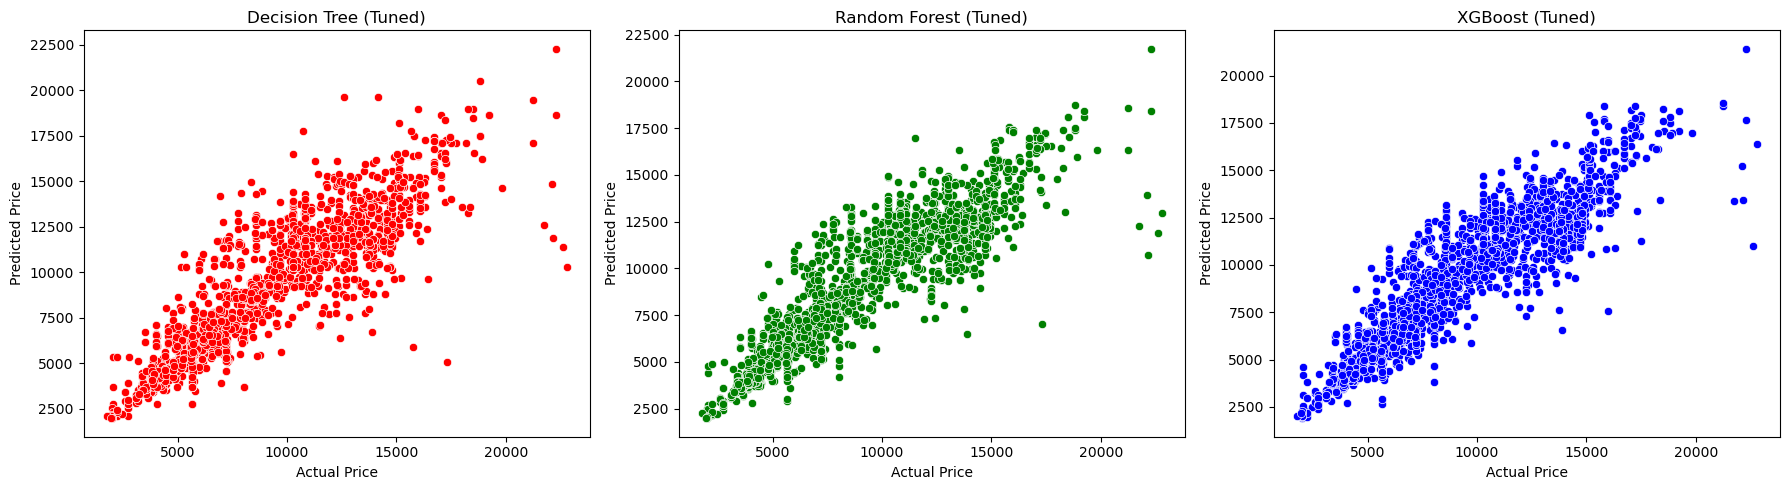

In [124]:
plt.figure(figsize=(18,5))

# Plot for tuned Random Forest Tuned
plt.subplot(1,3,2)
sns.scatterplot(x=y_test, y=y_pred_rf_tuned, color = 'green')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest (Tuned)")

# Plot for tuned Decision Tree 
plt.subplot(1,3,1)
sns.scatterplot(x=y_test, y=y_pred_dt_tuned, color = 'red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree (Tuned)")

# Plot for tuned XGBoost Tuned
plt.subplot(1,3,3)
sns.scatterplot(x=y_test, y=y_pred_xgb_tuned, color = 'blue')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost (Tuned)")

plt.tight_layout()
plt.show()


# Residual Plots for models

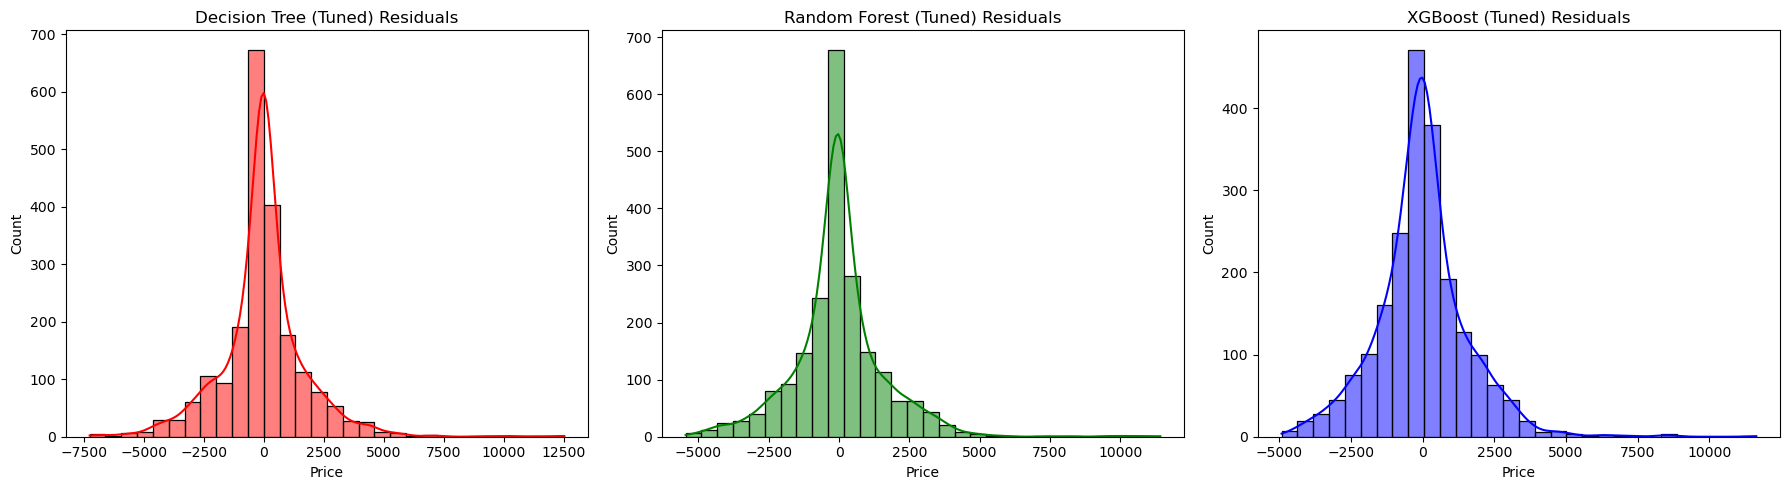

In [123]:
plt.figure(figsize=(18,5))

# Random Forest Tuned Residuals
plt.subplot(1,3,2)
residuals_rf = y_test - y_pred_rf_tuned
sns.histplot(residuals_rf, color = 'green', kde=True, bins=30)
plt.title("Random Forest (Tuned) Residuals")

# Decision Tree Tuned Residuals
plt.subplot(1,3,1)
residuals_dt = y_test - y_pred_dt_tuned
sns.histplot(residuals_dt,color = 'red', kde=True, bins=30)
plt.title("Decision Tree (Tuned) Residuals")

# XGBoost Tuned Residuals
plt.subplot(1,3,3)
residuals_xgb = y_test - y_pred_xgb_tuned
sns.histplot(residuals_xgb, color = 'blue', kde=True, bins=30)
plt.title("XGBoost (Tuned) Residuals")

plt.tight_layout()
plt.show()


In [145]:
results = {
    "Model" : ["Random Forest (Default)", "Random Forest (Tuned)","Decision Tree (Default)", 
               "Decision Tree (Tuned)","XGBoost (Default","XGBoost (Tuned)"],
    "r2_score" : ["0.8280", "0.8374" , "0.7035", "0.8053", "0.8437", "0.8457"],
    "mae" : ['1078.42', '1076.60', '1306.51', '1143.48', '1102.45','1122.07'],
    "rmse" : ["1672.43","1626.51","2196.22","1779.38","1594.63","1584.48"],
    "mean_cross_val" : ["not included","0.8419","not_included","0.7998","not_included", "0.8495"]
}

In [146]:
comparison = pd.DataFrame(results)

In [147]:
comparison

,Model,r2_score,mae,rmse,mean_cross_val
0,Random Forest (Default),0.8280,1078.42,1672.43,not included
1,Random Forest (Tuned),0.8374,1076.60,1626.51,0.8419
2,Decision Tree (Default),0.7035,1306.51,2196.22,not_included
3,Decision Tree (Tuned),0.8053,1143.48,1779.38,0.7998
4,XGBoost (Default,0.8437,1102.45,1594.63,not_included
5,XGBoost (Tuned),0.8457,1122.07,1584.48,0.8495


# Pikling - Saving the best model (XGBoost) 

In [148]:
import pickle

In [149]:
with open('tuned_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print("Tuned XGBoost model saved as 'tuned_xgb_model.pkl'")


Tuned XGBoost model saved as 'tuned_xgb_model.pkl'


In [151]:
# Load the model from the file
with open('tuned_xgb_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)


# Creating a test data to make predictions on saved model

In [169]:
test_data = pd.DataFrame({
    'Airline': [1, 3, 2],
    'Source': [0, 2, 1],
    'Destination': [2, 1, 3],
    'Total_Stops': [1, 0, 2],
    'Journey_day': [15, 22, 5],
    'Jorney_month': [6, 9, 12],  # <-- match typo in training
    'Dep_hr': [10, 18, 6],
    'Dep_min': [30, 45, 15],
    'Arrival_hr': [13, 20, 9],
    'Arrival_min': [15, 30, 50],
    'Total_duration_mins': [165, 165, 215]
})


In [170]:
test_data

,Airline,Source,Destination,Total_Stops,Journey_day,Jorney_month,Dep_hr,Dep_min,Arrival_hr,Arrival_min,Total_duration_mins
0,1,0,2,1,15,6,10,30,13,15,165
1,3,2,1,0,22,9,18,45,20,30,165
2,2,1,3,2,5,12,6,15,9,50,215


In [171]:
# Making Predictions
predicted_fares = loaded_model.predict(test_data)
print("Predicted Flight Fares:", predicted_fares)

Predicted Flight Fares: [ 4775.268   6090.5625 12622.287 ]


# Project Completion Report of Analysis and Model Building